Epoch 01 | Acc=0.491 | Φ*=0.000000
Epoch 02 | Acc=0.508 | Φ*=0.000000
Epoch 03 | Acc=0.508 | Φ*=0.000000
Epoch 04 | Acc=0.508 | Φ*=0.000000
Epoch 05 | Acc=0.508 | Φ*=0.000000
Epoch 06 | Acc=0.508 | Φ*=0.000000
Epoch 07 | Acc=0.508 | Φ*=0.000000
Epoch 08 | Acc=0.510 | Φ*=0.000000
Epoch 09 | Acc=0.508 | Φ*=0.000000
Epoch 10 | Acc=0.508 | Φ*=0.000000
Epoch 11 | Acc=0.503 | Φ*=0.000000
Epoch 12 | Acc=0.508 | Φ*=0.000000
Epoch 13 | Acc=0.508 | Φ*=0.000000
Epoch 14 | Acc=0.508 | Φ*=0.000000
Epoch 15 | Acc=0.508 | Φ*=0.000000
Epoch 16 | Acc=0.508 | Φ*=0.000000
Epoch 17 | Acc=0.508 | Φ*=0.000000
Epoch 18 | Acc=0.508 | Φ*=0.000000
Epoch 19 | Acc=0.508 | Φ*=0.000000
Epoch 20 | Acc=0.501 | Φ*=0.000000
Epoch 21 | Acc=0.508 | Φ*=0.000000
Epoch 22 | Acc=0.508 | Φ*=0.000000
Epoch 23 | Acc=0.508 | Φ*=0.000000
Epoch 24 | Acc=0.508 | Φ*=0.000000
Epoch 25 | Acc=0.508 | Φ*=0.067130
Epoch 26 | Acc=0.493 | Φ*=0.120438
Epoch 27 | Acc=0.508 | Φ*=0.130188
Epoch 28 | Acc=0.508 | Φ*=0.093393
Epoch 29 | Acc=0.508

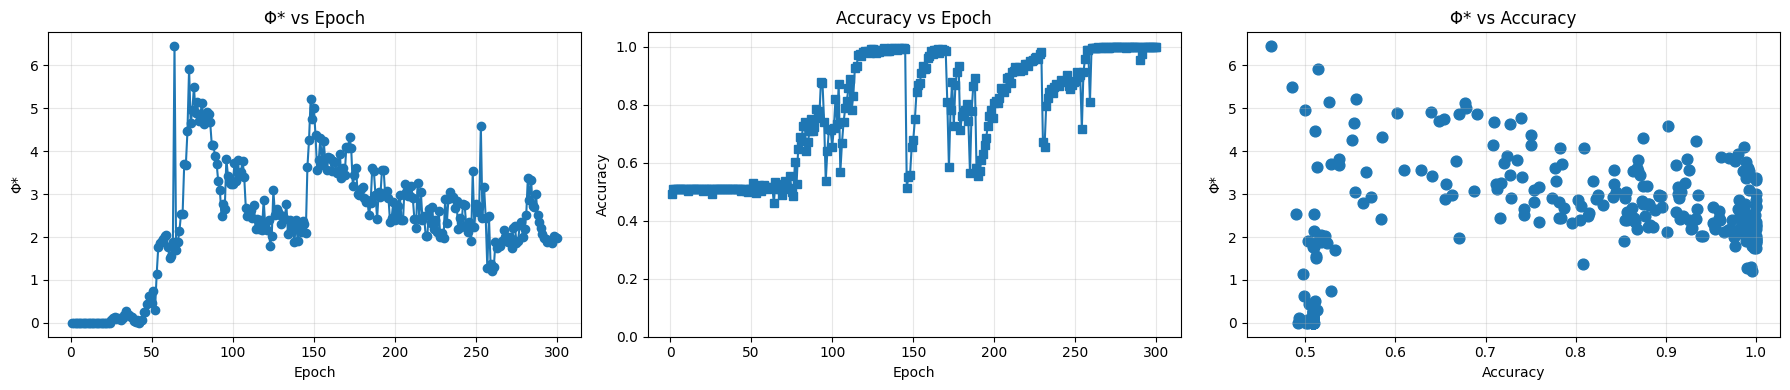

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# -------------------------------
# CONFIGURATION
# -------------------------------
device = "cpu"
HIDDEN_SIZE = 60
EPOCHS = 300
BATCH_SIZE = 32
LR = 0.001
MAX_N = 8

# -------------------------------
# Φ CONFIG
# -------------------------------
@dataclass
class PhiConfig:
    n_samples: int = 2000
    tau: int = 1
    n_partitions_sample: int = 20

# -------------------------------
# DATASET
# -------------------------------
symbol_to_idx = {'X':0,'Y':1,'A':2,'B':3,'EOS':4}

def generate_sequence():
    valid = np.random.rand() > 0.5
    rule = np.random.choice(['X','Y'])
    n = np.random.randint(1, MAX_N+1)

    seq = [rule] + ['A'] * n
    if rule == 'X':
        seq += ['B'] * (n if valid else n+np.random.choice([-1,1]))
    else:
        seq += ['B'] * (2*n if valid else 2*n+np.random.choice([-1,1]))

    seq.append('EOS')
    onehot = np.eye(5)[[symbol_to_idx[s] for s in seq]]
    return onehot, float(valid)

class GrammarDataset(Dataset):
    def __init__(self, n_samples=3000):
        self.data = [generate_sequence() for _ in range(n_samples)]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x,dtype=torch.float32), torch.tensor(y)

def collate(batch):
    xs, ys = zip(*batch)
    max_len = max(x.shape[0] for x in xs)
    padded = []
    for x in xs:
        pad = torch.zeros(max_len-x.shape[0],5)
        padded.append(torch.cat([x,pad],0))
    return torch.stack(padded), torch.tensor(ys)

# -------------------------------
# GRU MODEL
# -------------------------------
class GrammarGRU(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.gru = nn.GRU(5, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):
        _,h = self.gru(x)
        return torch.sigmoid(self.fc(h.squeeze(0))), h

# -------------------------------
# HIDDEN STATE COLLECTION
# -------------------------------
def collect_hidden_states(model, n_samples=2000):
    states = []
    h = None
    with torch.no_grad():
        for _ in range(n_samples):
            x = torch.eye(5)[np.random.randint(0,5)].view(1,1,-1)
            _, h = model.gru(x, h)
            states.append(h.squeeze().cpu().numpy())
    return np.array(states)

# -------------------------------
# STOCHASTIC Φ*
# -------------------------------
class BarrettSethPhiStar:
    """
    TRUE Barrett & Seth (2011) Φ* for continuous Gaussian systems
    Monte-Carlo approximation of the Minimum Information Partition (MIP)
    """

    def __init__(self, config):
        self.config = config

    def gaussian_mi(self, X, Y):
        """Gaussian mutual information I(X;Y)"""
        n = X.shape[1]
        reg = 1e-6 * np.eye(n)

        Cov_X = np.cov(X.T) + reg
        Cov_Y = np.cov(Y.T) + reg
        Cov_XY = np.cov(np.hstack([X, Y]).T) + 1e-6 * np.eye(2*n)

        sx, logdet_x = np.linalg.slogdet(Cov_X)
        sy, logdet_y = np.linalg.slogdet(Cov_Y)
        sxy, logdet_xy = np.linalg.slogdet(Cov_XY)

        if sx <= 0 or sy <= 0 or sxy <= 0:
            return 0.0

        return 0.5 * (logdet_x + logdet_y - logdet_xy) / np.log(2)

    def estimate(self, states):
        X = states[:-self.config.tau]
        Y = states[self.config.tau:]

        n_samples, n_dim = X.shape

        # ---- Whole system information ----
        I_whole = self.gaussian_mi(X, Y)

        if I_whole <= 0:
            return 0.0

        min_I_partition = np.inf
        nodes = np.arange(n_dim)

        np.random.seed(42)

        # ---- Monte-Carlo MIP search ----
        for _ in range(self.config.n_partitions_sample):

            k = np.random.randint(1, n_dim // 2 + 1)
            A = np.random.choice(nodes, k, replace=False)
            B = np.array(list(set(nodes) - set(A)))

            if len(B) == 0:
                continue

            I_A = self.gaussian_mi(X[:, A], Y[:, A])
            I_B = self.gaussian_mi(X[:, B], Y[:, B])

            I_partition = I_A + I_B
            min_I_partition = min(min_I_partition, I_partition)

        phi_star = I_whole - min_I_partition
        return max(phi_star, 0.0)

# -------------------------------
# TRAINING LOOP WITH Φ*
# -------------------------------
def train_with_phi_tracking(config: PhiConfig, phi_samples_per_epoch=500):

    model = GrammarGRU(HIDDEN_SIZE).to(device)
    loader = DataLoader(GrammarDataset(), batch_size=BATCH_SIZE,
                        shuffle=True, collate_fn=collate)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()

    phi_estimator = BarrettSethPhiStar(config)


    phi_history = []
    acc_history = []

    for epoch in range(1, EPOCHS+1):

        # ---- TRAIN ----
        model.train()
        for x,y in loader:
            optimizer.zero_grad()
            pred,_ = model(x)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

        # ---- ACCURACY ----
        model.eval()
        correct,total = 0,0
        with torch.no_grad():
            for x,y in loader:
                pred,_ = model(x)
                pred = (pred.squeeze()>0.5).float()
                correct += (pred==y).sum().item()
                total += y.size(0)
        acc = correct/total
        acc_history.append(acc)

        # ---- Φ* ----
        states = collect_hidden_states(model, phi_samples_per_epoch)
        phi = phi_estimator.estimate(states)
        phi_history.append(phi)


        print(f"Epoch {epoch:02d} | Acc={acc:.3f} | Φ*={phi:.6f}")

    return phi_history, acc_history

# -------------------------------
# VISUALIZATION
# -------------------------------
# -------------------------------
# VISUALIZATION
# -------------------------------
def plot_results(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history)+1)

    plt.figure(figsize=(18,4))

    # ---------------- Φ* vs Epoch ----------------
    plt.subplot(1,3,1)
    plt.plot(epochs, phi_history, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Epoch")
    plt.grid(alpha=0.3)

    # ---------------- Accuracy vs Epoch ----------------
    plt.subplot(1,3,2)
    plt.plot(epochs, acc_history, marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epoch")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)

    # ---------------- Φ* vs Accuracy ----------------
    plt.subplot(1,3,3)
    plt.scatter(acc_history, phi_history, s=60)
    plt.xlabel("Accuracy")
    plt.ylabel("Φ*")
    plt.title("Φ* vs Accuracy")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# -------------------------------
# MAIN
# -------------------------------
if __name__ == "__main__":

    config = PhiConfig(
        n_samples=2000,
        tau=1,
        n_partitions_sample=20
    )

    phi_hist, acc_hist = train_with_phi_tracking(
        config,
        phi_samples_per_epoch=2000
    )

    plot_results(phi_hist, acc_hist)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# SAVE DIRECTORY (Google Colab)
# -------------------------------
SAVE_DIR = "/content/phi_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# BIG, CLEAR PLOTS + SAVE
# -------------------------------
def plot_and_save_results(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history) + 1)

    # ---------- Φ* vs Epoch ----------
    plt.figure(figsize=(12, 7))
    plt.plot(epochs, phi_history, linewidth=2.5)
    plt.xlabel("Epoch", fontsize=16)
    plt.ylabel("Φ*", fontsize=16)
    plt.title("Φ* vs Epoch", fontsize=18)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/phi_vs_epoch.png", dpi=300)
    plt.show()

    # ---------- Accuracy vs Epoch ----------
    plt.figure(figsize=(12, 7))
    plt.plot(epochs, acc_history, linewidth=2.5)
    plt.xlabel("Epoch", fontsize=16)
    plt.ylabel("Accuracy", fontsize=16)
    plt.title("Accuracy vs Epoch", fontsize=18)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/accuracy_vs_epoch.png", dpi=300)
    plt.show()

    # ---------- Φ* vs Accuracy ----------
    plt.figure(figsize=(12, 7))
    plt.scatter(acc_history, phi_history, s=90)
    plt.xlabel("Accuracy", fontsize=16)
    plt.ylabel("Φ*", fontsize=16)
    plt.title("Φ* vs Accuracy", fontsize=18)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/phi_vs_accuracy.png", dpi=300)
    plt.show()

    print(" Saved inside Colab at:", SAVE_DIR)


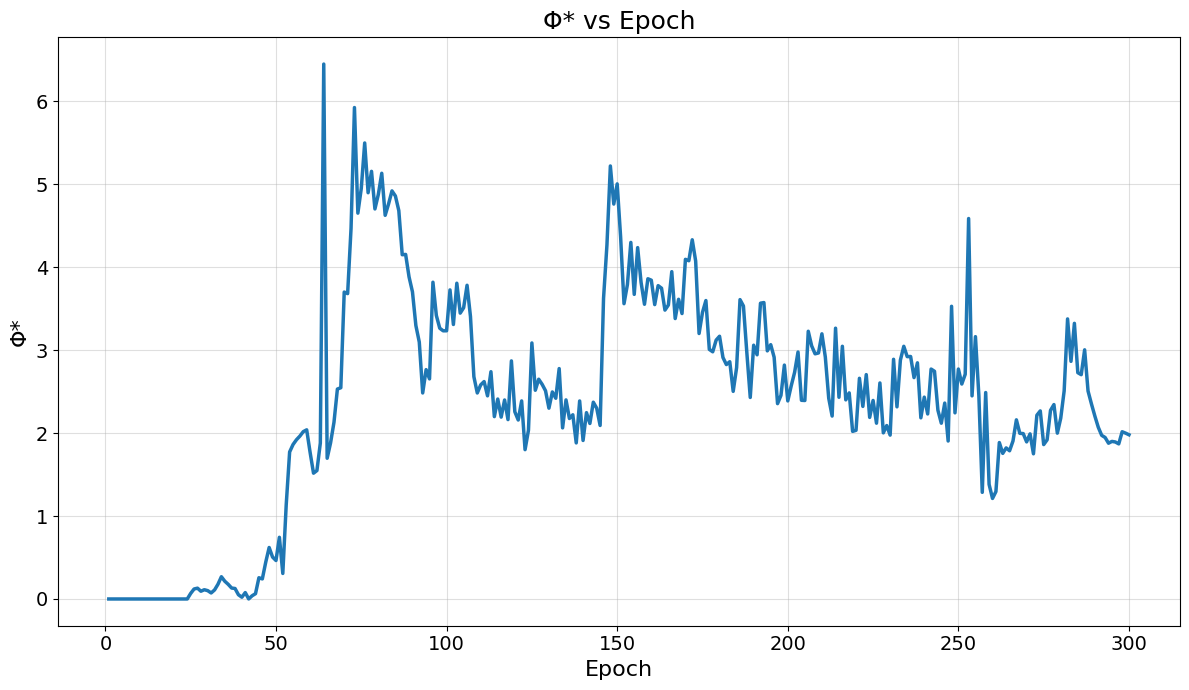

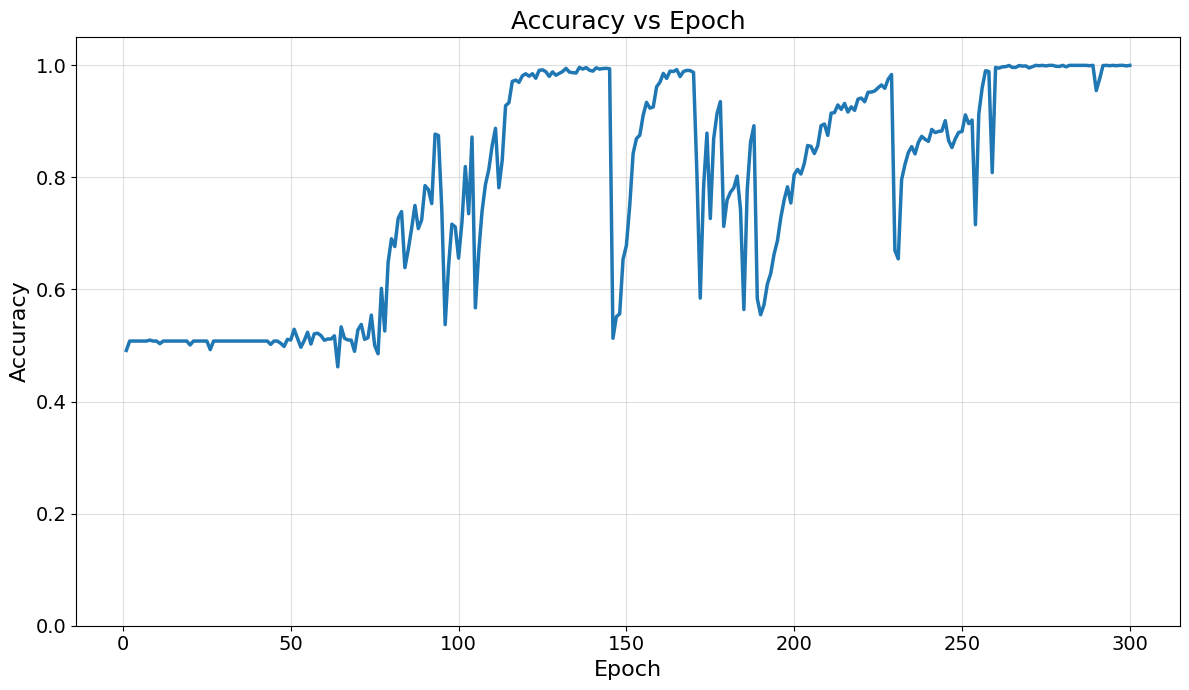

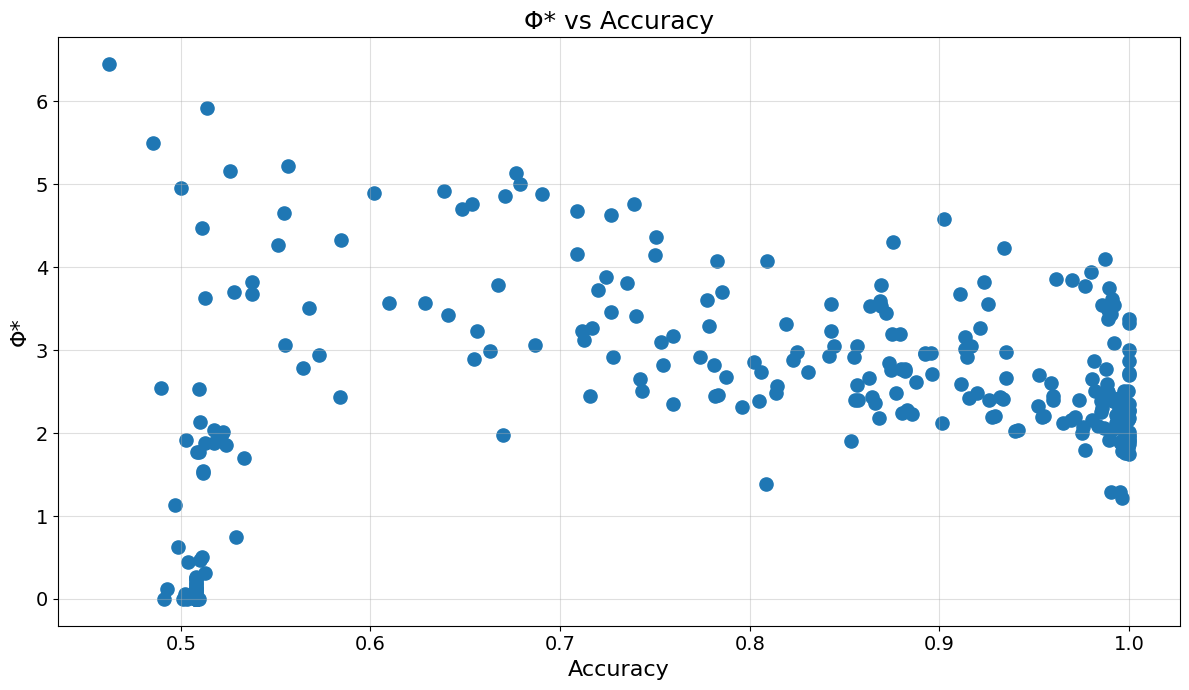

 Saved inside Colab at: /content/phi_results


In [ ]:
plot_and_save_results(phi_hist, acc_hist)



# Finding the correlation between the phi and accuracy
It is mainly to see how much the phi and accuracy value are correlated

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# -------------------------------
# SAVE DIRECTORY (Colab)
# -------------------------------
SAVE_DIR = "/content/phi_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# CORRELATION PLOT
# -------------------------------
def plot_and_save_phi_accuracy_correlation(phi_history, acc_history):

    phi = np.array(phi_history)
    acc = np.array(acc_history)

    # Pearson correlation
    r, p = pearsonr(acc, phi)

    plt.figure(figsize=(12, 7))
    plt.scatter(acc, phi, s=100, alpha=0.8)
    plt.xlabel("Accuracy", fontsize=16)
    plt.ylabel("Φ*", fontsize=16)
    plt.title("Correlation between Φ* and Accuracy", fontsize=18)

    # Annotate correlation
    plt.text(
        0.05, 0.95,
        f"Pearson r = {r:.3f}\np-value = {p:.3e}",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.3)
    )

    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/phi_accuracy_correlation.png", dpi=300)
    plt.show()

    print(" Correlation plot saved at:", SAVE_DIR)
    print(f"Pearson r = {r:.3f}, p = {p:.3e}")


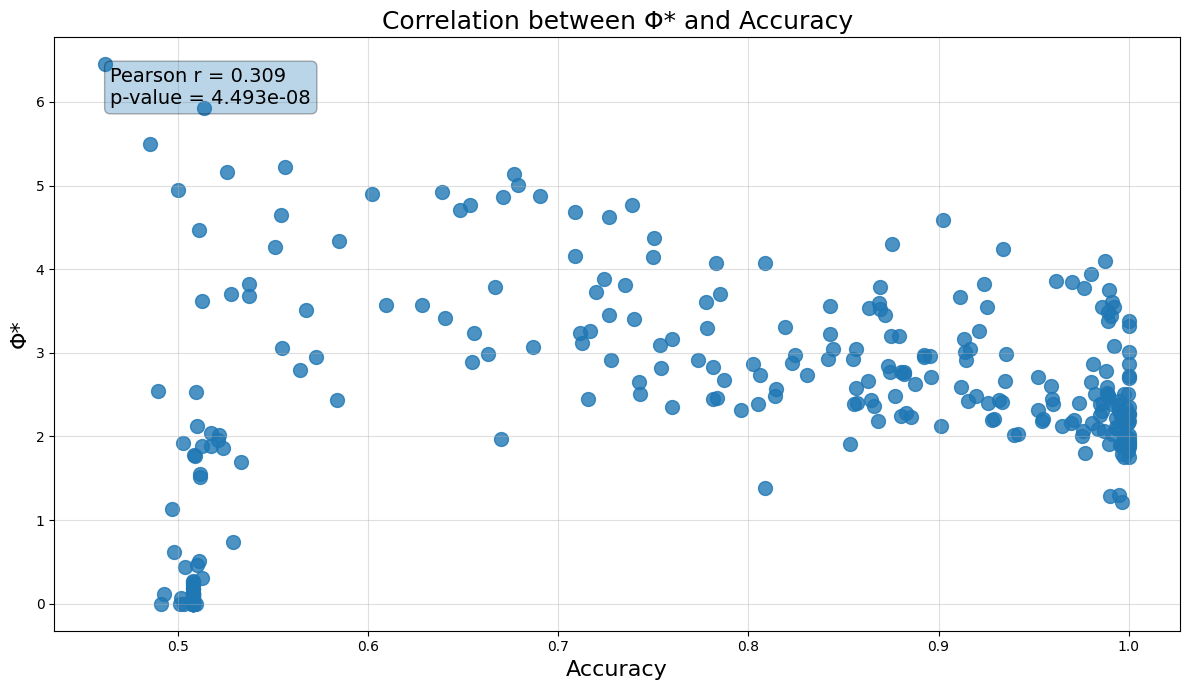

 Correlation plot saved at: /content/phi_results
Pearson r = 0.309, p = 4.493e-08


In [ ]:
plot_and_save_phi_accuracy_correlation(phi_hist, acc_hist)


# Saving the result in CSV file

In [ ]:
import os
import pandas as pd
import numpy as np

# -------------------------------
# SAVE DIRECTORY (Colab)
# -------------------------------
SAVE_DIR = "/content/phi_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# SAVE CSV FILES
# -------------------------------
def save_results_to_csv(phi_history, acc_history):

    epochs = np.arange(1, len(phi_history) + 1)

    # ---- Φ vs Epoch ----
    df_phi_epoch = pd.DataFrame({
        "epoch": epochs,
        "phi": phi_history
    })
    df_phi_epoch.to_csv(f"{SAVE_DIR}/phi_vs_epoch.csv", index=False)

    # ---- Accuracy vs Epoch ----
    df_acc_epoch = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history
    })
    df_acc_epoch.to_csv(f"{SAVE_DIR}/accuracy_vs_epoch.csv", index=False)

    # ---- Φ vs Accuracy ----
    df_phi_acc = pd.DataFrame({
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_phi_acc.to_csv(f"{SAVE_DIR}/phi_vs_accuracy.csv", index=False)

    # ---- Combined ----
    df_full = pd.DataFrame({
        "epoch": epochs,
        "accuracy": acc_history,
        "phi": phi_history
    })
    df_full.to_csv(f"{SAVE_DIR}/training_summary.csv", index=False)

    print("CSV files saved in:", SAVE_DIR)

save_results_to_csv(phi_hist, acc_hist)



CSV files saved in: /content/phi_results
